In [2]:
import sys
!{sys.executable} -m pip install torch torchvision

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 MB 13.0 MB/s  0:00:06 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 10.4 MB/s  0:00:000.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 9.1 MB/s  0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [torchvision] 7/8 [torchvision]


In [3]:
import os
import copy
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

In [ ]:

CSV_PATH = "HAM10000_metadata.csv"
IMG_DIR_1 = "HAM10000_images_part_1"
IMG_DIR_2 = "HAM10000_images_part_2"

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].copy()

def get_image_path(image_id):
    p1 = os.path.join(IMG_DIR_1, f"{image_id}.jpg")
    p2 = os.path.join(IMG_DIR_2, f"{image_id}.jpg")
    if os.path.exists(p1):
        return p1
    if os.path.exists(p2):
        return p2
    return None

df["path"] = df["image_id"].apply(get_image_path)
df = df[df["path"].notnull()].reset_index(drop=True)

print("Usable images:", len(df))
print("\nClass distribution:")
print(df["dx"].value_counts())

Usable images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

num_classes = len(label_encoder.classes_)
print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)


Label mapping:
0 akiec
1 bcc
2 bkl
3 df
4 mel
5 nv
6 vasc


In [ ]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("\nTrain size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))


Train size: 7010
Val size: 1502
Test size: 1503


In [ ]:

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = HAM10000Dataset(train_df, transform=train_transform)
val_dataset = HAM10000Dataset(val_df, transform=eval_transform)
test_dataset = HAM10000Dataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("\nClass weights:")
for i, w in enumerate(class_weights.cpu().numpy()):
    print(label_encoder.classes_[i], ":", round(float(w), 3))


Class weights:
akiec : 4.373
bcc : 2.782
bkl : 1.302
df : 12.363
mel : 1.286
nv : 0.213
vasc : 10.115


In [ ]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=num_classes).to(DEVICE)
print("\nModel loaded on:", DEVICE)


Model loaded on: cpu


In [ ]:

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    num_batches = len(loader)

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 20 == 0 or (batch_idx + 1) == num_batches:
            print(f"    Batch {batch_idx+1}/{num_batches} complete")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [ ]:

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# Load best validation model
model.load_state_dict(best_model_wts)

    Batch 20/220 complete
    Batch 40/220 complete
    Batch 60/220 complete
    Batch 80/220 complete
    Batch 100/220 complete
    Batch 120/220 complete
    Batch 140/220 complete
    Batch 160/220 complete
    Batch 180/220 complete
    Batch 200/220 complete
    Batch 220/220 complete
Epoch 1/15
  Train Loss: 1.5273 | Train Acc: 0.4852
  Val   Loss: 1.4709 | Val   Acc: 0.5439
    Batch 20/220 complete
    Batch 40/220 complete
    Batch 60/220 complete
    Batch 80/220 complete
    Batch 100/220 complete
    Batch 120/220 complete
    Batch 140/220 complete
    Batch 160/220 complete
    Batch 180/220 complete
    Batch 200/220 complete
    Batch 220/220 complete
Epoch 2/15
  Train Loss: 1.4534 | Train Acc: 0.4912
  Val   Loss: 1.4511 | Val   Acc: 0.5546
    Batch 20/220 complete
    Batch 40/220 complete
    Batch 60/220 complete
    Batch 80/220 complete
    Batch 100/220 complete
    Batch 120/220 complete
    Batch 140/220 complete
    Batch 160/220 complete
    Batch 180/22

<All keys matched successfully>

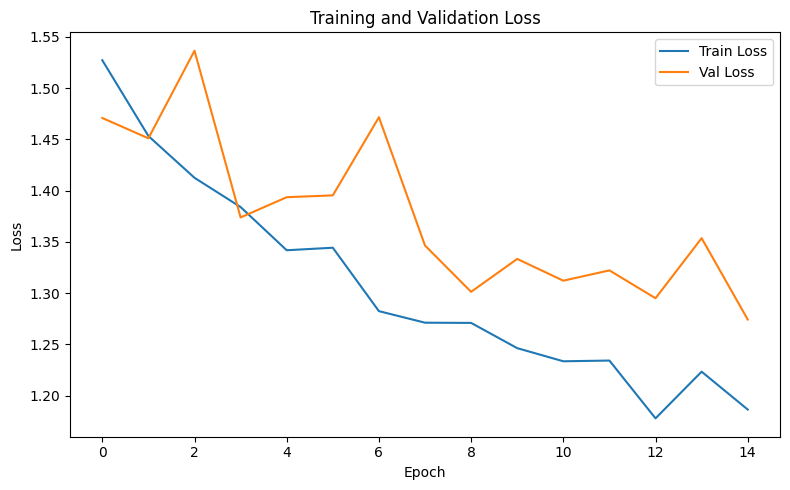

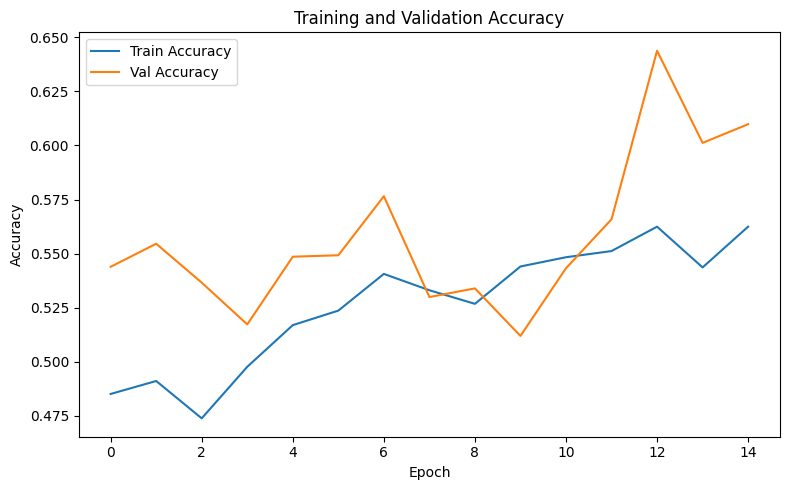

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, DEVICE)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# melanoma recall
mel_index = label_encoder.transform(["mel"])[0]
mel_mask = (y_true == mel_index)
mel_recall = ((y_pred[mel_mask] == mel_index).sum() / mel_mask.sum()) if mel_mask.sum() > 0 else 0.0
print("\nMelanoma Recall:", round(float(mel_recall), 4))


Test Loss: 1.2535
Test Accuracy: 0.6281

Classification Report:
              precision    recall  f1-score   support

       akiec       0.24      0.37      0.29        49
         bcc       0.32      0.44      0.37        77
         bkl       0.34      0.48      0.40       165
          df       0.10      0.35      0.15        17
         mel       0.38      0.46      0.42       167
          nv       0.92      0.71      0.80      1006
        vasc       0.28      0.73      0.40        22

    accuracy                           0.63      1503
   macro avg       0.37      0.50      0.41      1503
weighted avg       0.73      0.63      0.66      1503


Confusion Matrix:
[[ 18  11   7  10   1   2   0]
 [  4  34   9  17   2   4   7]
 [ 10  19  79  14  19  21   3]
 [  4   4   0   6   1   2   0]
 [ 13   9  34   1  76  27   7]
 [ 26  28 102  11  99 715  25]
 [  0   0   0   2   1   3  16]]

Melanoma Recall: 0.4551


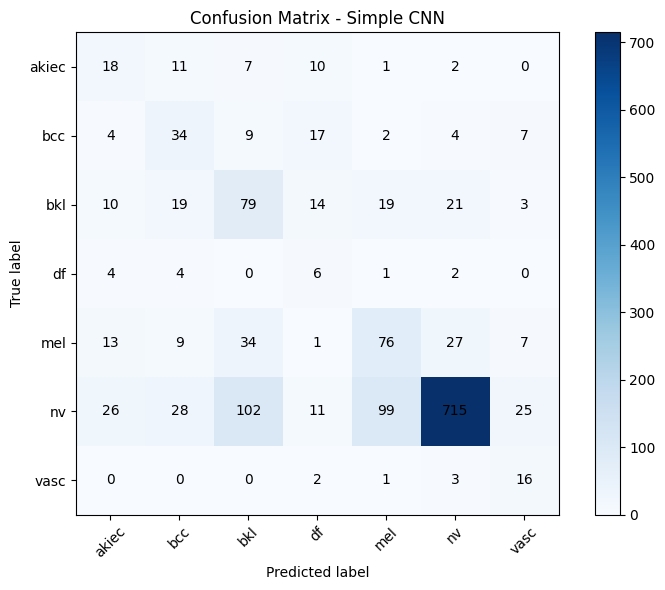

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Simple CNN")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

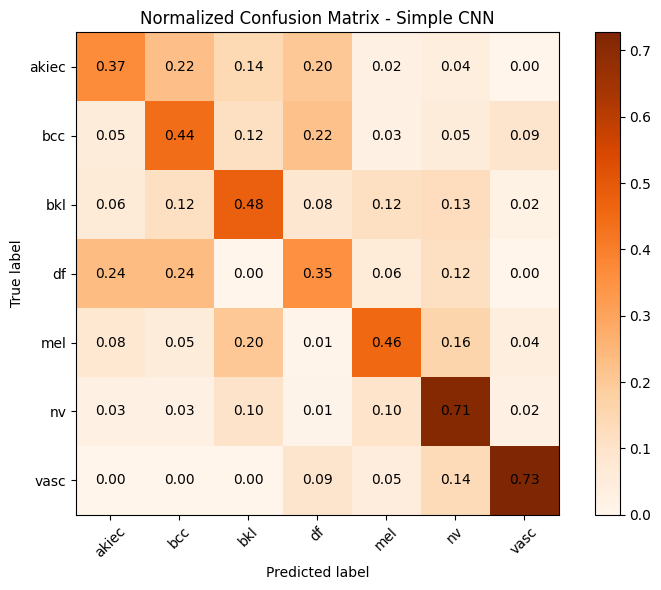

In [ ]:

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, interpolation="nearest", cmap="Oranges")
plt.title("Normalized Confusion Matrix - Simple CNN")
plt.colorbar()

plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

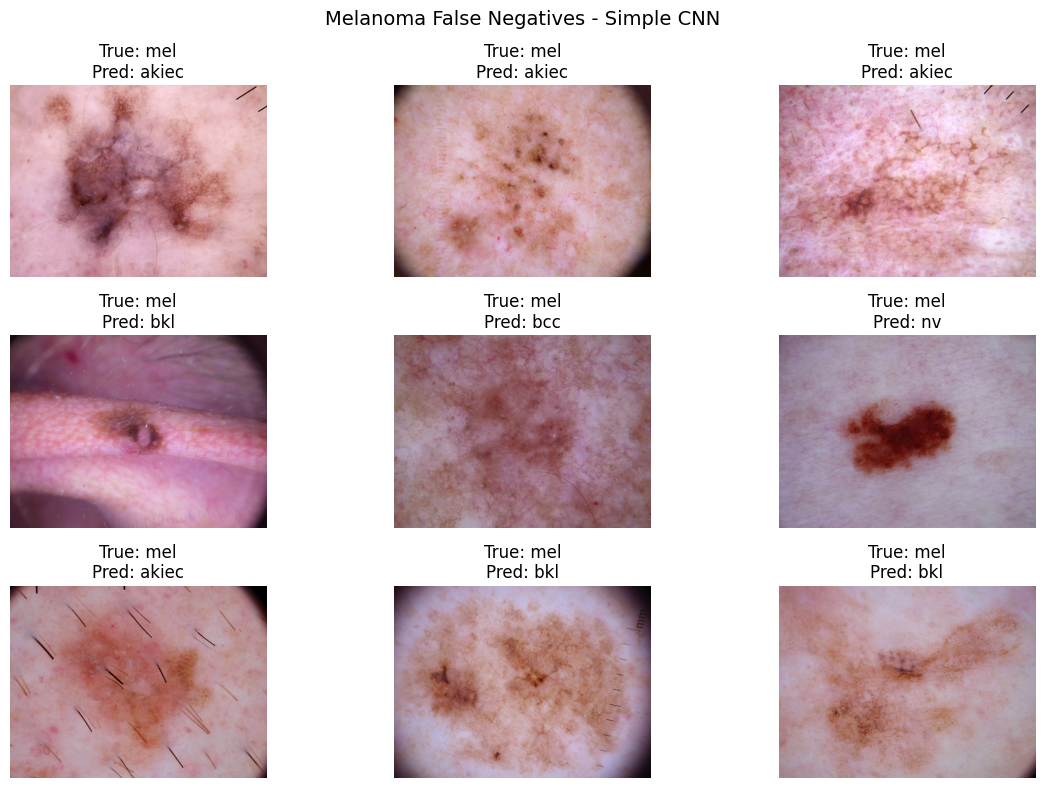

In [ ]:

fn_indices = np.where((y_true == mel_index) & (y_pred != mel_index))[0]

num_show = min(9, len(fn_indices))
plt.figure(figsize=(12, 8))

for i, idx in enumerate(fn_indices[:num_show]):
    plt.subplot(3, 3, i + 1)
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)

    true_label = label_encoder.inverse_transform([y_true[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Melanoma False Negatives - Simple CNN", fontsize=14)
plt.tight_layout()
plt.show()

Compared to classical machine learning models, the baseline CNN reduced melanoma false negatives by significantly improving melanoma recall. This improvement came at the cost of slightly lower overall accuracy due to the model placing greater emphasis on minority classes through weighted loss.